In [1]:
#from numpy.random import seed
#seed(432)
# from tensorflow.random import set_seed
# set_seed(432)
import sys
import os

from tensorflow.keras.utils import set_random_seed
from skimage import img_as_ubyte
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.axes_grid1 import make_axes_locatable

sys.path.append('/home/jovyan/projects/onunet')
from model import *
from data import *
from pathlib import Path

print(os.getcwd())
os.chdir('/home/jovyan/projects/onunet')
print(os.getcwd())
path2data = "/home/jovyan/kDrive/cellcount/data/onunet/optical_nerve"
path2train = os.path.join(path2data, "train")
print(path2train)
path2validation = os.path.join(path2data, "validation")
print(path2validation)
path2test = os.path.join(path2data, "test")
print(path2test)
path2checkpoints = "/home/jovyan/kDrive/cellcount/data/onunet/model_weights"

2024-02-14 09:31:13.563614: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-02-14 09:31:13.603803: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-02-14 09:31:13.605051: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-02-14 09:31:14.509663: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


/home/jovyan
/home/jovyan/projects/onunet
/home/jovyan/kDrive/cellcount/data/onunet/optical_nerve/train
/home/jovyan/kDrive/cellcount/data/onunet/optical_nerve/validation
/home/jovyan/kDrive/cellcount/data/onunet/optical_nerve/test


In [2]:
# Set the seed using keras.utils.set_random_seed. This will set:
# 1) `numpy` seed
# 2) backend random seed
# 3) `python` random seed
set_random_seed(812)

### Train with data generator

In [3]:
# Set training settings:
HP = dict(
    batch_size=1,
    epochs=2,
    steps_per_epoch=5,
    validation_steps=1
)

In [4]:
data_gen_args = dict(rotation_range = 0.2,
                    width_shift_range = 0.05,
                    height_shift_range = 0.05,
                    shear_range = 0.05,
                    zoom_range = 0.05,
                    horizontal_flip = True,
                    vertical_flip = True,
                    fill_mode = 'nearest')
augmented_data = os.path.join(path2train, "img_generator")

train_generator = trainGenerator(
    batch_size=HP['batch_size'],
    train_path=path2train,
    image_folder='images',
    mask_folder='labels',
    weight_folder='weights',
    aug_dict=data_gen_args,
    #save_to_dir=augmented_data,
    #target_size=(256, 256)
    target_size=(512, 512)
)

validation_generator = validationGenerator(
    batch_size=HP['batch_size'],
    validation_path=path2validation,
    image_folder='images',
    mask_folder='labels',
    weight_folder='weights',
    #aug_dict=data_gen_args,
    #save_to_dir=augmented_data,
    #target_size=(256, 256)
    target_size=(512, 512)
)


In [5]:
## sanity check:
num_batch = 5
for i, batch in enumerate(train_generator):
    inputs = batch[0]
    #targets = batch[1]
    image = inputs[0]
    print(f"image: min value is {np.min(image)} ; max value is {np.max(image)}")
    label = inputs[1]
    print(f"label: min value is {np.min(label)} ; max value is {np.max(label)}")
    weights = inputs[2]
    print(f"weights: min value is {np.min(weights)} ; max value is {np.max(weights)}")
    print('images batch shape :', image.shape)
    print('labels batch shape :', label.shape)
    print('weights batch shape :', weights.shape)

    if i == num_batch:
        break

Found 20 images belonging to 1 classes.
Found 20 images belonging to 1 classes.
Found 20 images belonging to 1 classes.


image: min value is 0.0842803493142128 ; max value is 0.8938171863555908
label: min value is 0.0 ; max value is 1.0
weights: min value is 0.986967921257019 ; max value is 3.6060404777526855
images batch shape : (1, 512, 512, 1)
labels batch shape : (1, 512, 512, 1)
weights batch shape : (1, 512, 512, 1)
image: min value is 0.09215480834245682 ; max value is 0.7698708176612854
label: min value is 0.0 ; max value is 1.0
weights: min value is 0.986967921257019 ; max value is 3.6467092037200928
images batch shape : (1, 512, 512, 1)
labels batch shape : (1, 512, 512, 1)
weights batch shape : (1, 512, 512, 1)
image: min value is 0.0235294122248888 ; max value is 0.7967517375946045
label: min value is 0.0 ; max value is 1.0
weights: min value is 0.986967921257019 ; max value is 3.6378910541534424
images batch shape : (1, 512, 512, 1)
labels batch shape : (1, 512, 512, 1)
weights batch shape : (1, 512, 512, 1)
image: min value is 0.1573241800069809 ; max value is 0.8581043481826782
label: min 

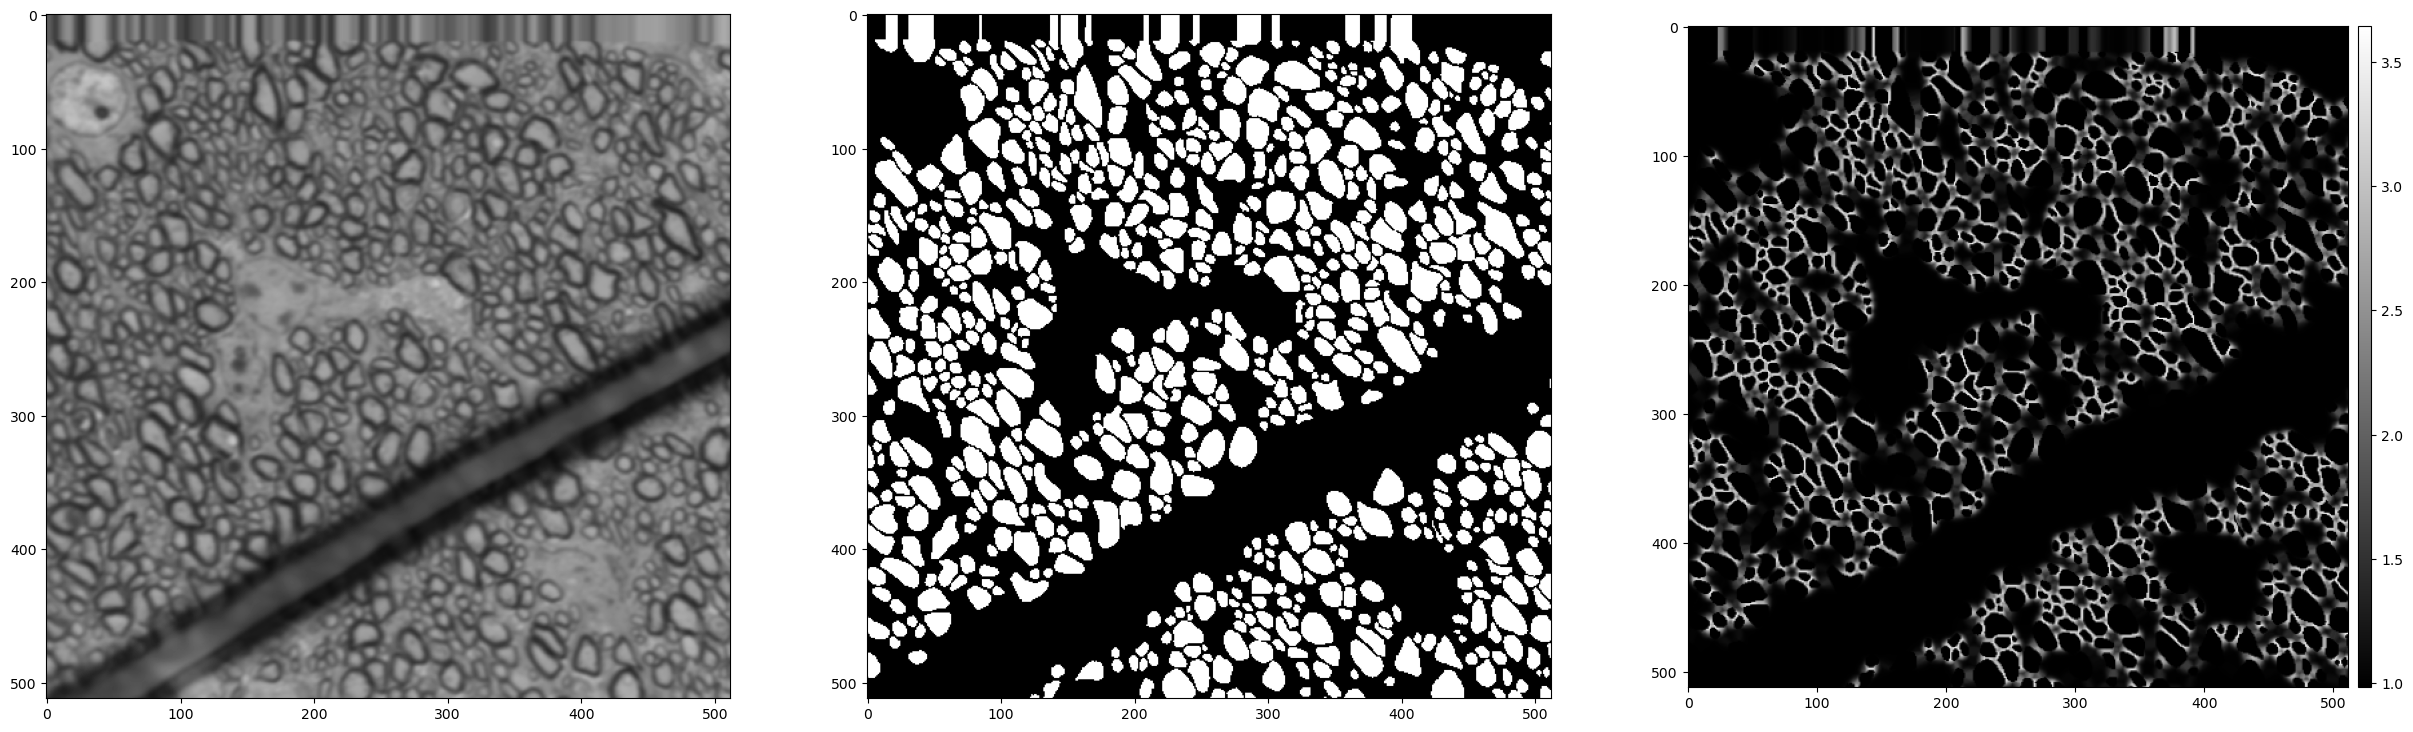

In [6]:
fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(30,10))
img = ax1.imshow(np.squeeze(image), cmap='gray', vmin=0, vmax=1)
img_mask = ax2.imshow(np.squeeze(label), cmap='gray', vmin=0, vmax=1)
img_weights = ax3.imshow(np.squeeze(weights), cmap='gray')
# create an axes on the right side of ax. The width of cax will be 5%
# of ax and the padding between cax and ax will be fixed at 0.05 inch.
divider = make_axes_locatable(ax3)
cax3 = divider.append_axes("right", size="2%", pad=0.1) 
plt.colorbar(img_weights, cax=cax3)

## Test custom loss function

In [74]:
def pixel_weighted_cross_entropy(weights, targets, predictions):
    pixel_losses = losses.binary_crossentropy(targets, predictions)
    #print(pixel_losses)
    squeezed_weights = reduce_mean(weights, axis=3, name='drop_one_dim_weights')
    #print(squeezed_weights)
    weighted_loss_val = multiply(squeezed_weights,
                                 pixel_losses,
                                 name='multiply_pixelwise_bce_by_weights'
                                )
    #print(weighted_loss_val)
    output_loss = reduce_mean(weighted_loss_val, name='average_weighted_pixel_losses')
    return output_loss
    

In [96]:
# Define input tensors of shape (batch_size, img_height, img_width, nb of classes):
y_true = np.expand_dims(np.array([[[0, 1, 0], [0, 1, 1], [0, 0, 0]], [[0, 0, 0], [0, 1, 0], [0, 1, 0]]]), axis=3)
print(y_true.shape)
y_pred = np.expand_dims(np.array([[[0.8, 0.9, 0.1], [0.2, 0.9, 0.5], [0.1, 0.4, 0]], [[0.1, 0.2, 0], [0.2, 0.6, 0.3], [0.2, 0.9, 0.3]]]), axis=3)
print(y_pred.shape)
weights = np.expand_dims(np.array([[[1., 2., 1.], [1., 4., 1.], [1., 1., 2.]], [[3., 3., 1.], [6., 2., 1.], [1., 1., 3.]]]), axis=3)
#weights = np.expand_dims(np.array([[[1., 1., 1.], [1., 1., 1.], [1., 1., 1.]], [[1., 1., 1.], [1., 1., 1.], [1., 1., 1.]]]), axis=3)
print(weights.shape)

(2, 3, 3, 1)
(2, 3, 3, 1)
(2, 3, 3, 1)


In [86]:
from math import log
epsilon = 1e-7 # as defined in Keras
y = 1
p = 0.9
bce = -(y * log(p + epsilon) + (1-y) * log(1-p + epsilon))
bce

0.1053604045467214

In [84]:
losses.binary_crossentropy(y_true, y_pred)

<tf.Tensor: shape=(2, 3, 3), dtype=float64, numpy=
array([[[ 0.1053604 ,  0.1053604 ,  0.1053604 ],
        [ 0.22314343,  0.1053604 ,  0.69314698],
        [ 0.1053604 ,  0.51082546, -0.        ]],

       [[ 0.1053604 ,  0.22314343, -0.        ],
        [ 0.22314343,  0.51082546,  0.3566748 ],
        [ 0.22314343,  0.1053604 ,  0.3566748 ]]])>

In [97]:
pixel_weighted_cross_entropy(weights, y_true, y_pred)

<tf.Tensor: shape=(), dtype=float64, numpy=0.4989256951464252>

In [ ]:
#pixel_weighted_cross_entropy(weights, targets, predictions)